# Simulate a sky background with realistic background galaxies and Milky Way stars

This notebook shows how to generate a sky background model including background galaxies and MW stars. You are encouraged to use the script at `rosesim/scripts/sim_sky.py`. 

In [3]:
# Import packages
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.io import fits
from astropy.wcs import WCS

import os, sys
sys.path.append('/home/jiaxuanl/Research/SALAD/script/')
os.chdir('/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
import asdf
from astroquery.gaia import Gaia
from astropy.coordinates import SkyCoord
from astropy.time import Time
from astropy.table import Table, vstack, Column, hstack
from astropy import units as u
from astropy.visualization import simple_norm
import copy
import galsim
import roman_datamodels as rdm
from romanisim import gaia, bandpass, catalog, log, wcs, persistence, parameters, ris_make_utils as ris
from romanisim.image import inject_sources_into_l2
from romanisim.l3 import inject_sources_into_l3

## 1. Load JAGUAR background galaxies. 

JAGUAR is a simulated galaxy catalog, designed for JWST work. See here for more details: https://fenrir.as.arizona.edu/jaguar/download_jaguar_files.html

The catalog needs to be requested from that website. You can email me if you really want to use this catalog. 

In [5]:
# cat_Q = Table.read("/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/JAGUAR/JADES_Q_mock_r1_v1.2.fits")
# cat_SF = Table.read("/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/JAGUAR/JADES_SF_mock_r1_v1.2.fits")
# cat_all = vstack([cat_Q, cat_SF])
# cat_all = cat_all[(cat_all['sersic_n'] < 6) & (cat_all['sersic_n'] > 0.35)]
# cat_all.write('/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/JAGUAR/JADES_all_mock_r1_v1.2.fits')

## 2. Artpop and make catalogs for Romanisim

In [6]:
import os
os.environ['NUMEXPR_MAX_THREADS'] = "30"
os.environ['ROSESIM_DATA_PATH'] = "/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/"

import artpop
import rosesim
from rosesim.rose import RomanGalaxy, RomanSky
rng = np.random.RandomState(100)

In [7]:
# This is chosen randomly. The MW stars from TRILEGAL are actually around this location.
obs_ra = 150.1049 #270.95
obs_dec = 2.2741 # -0.2

In [27]:
s = 1001 # size of the frame
sky = RomanSky(obs_ra, obs_dec, xy_dim=np.array([s, s]), prefix='sky_jaguar_test')
radius = sky.xy_dim[0] * 0.11 / 3600
sky.obs_time = Time('2025-01-01T00:00:00')
# sky.load_gaia_star(radius=radius)
sky.load_trilegal_star(radius=radius)
sky.load_jaguar_bkg(radius=radius, seed=42)
sky.gen_catalog(include_bkg=False, include_star=False)

Warning -- need to figure out the coefficients between JWST and Roman filters.
No sources to be included, so it will generate an empty sky.


/home/jiaxuanl/Research/Rosesim/rosesim/utils.py:138: RuntimeWarning: divide by zero encountered in log10
  cat_all = cat_all[-2.5 * np.log10(cat_all['HST_F606W_fnu'] * 1e-9 / 3631) < 28] # remove sources with F606W flux < 0.1 nJy


In [33]:
exptime = 642 # HLWAS
sky.observe('F158', exptime=exptime)
sky.observe('F106', exptime=exptime)
sky.observe('F129', exptime=exptime)

Making mock Roman L3 image in F158 for sky_jaguar_test


2025-12-17 17:08:29 INFO     Starting simulation...
2025-12-17 17:08:29 WARNING  romanisim is under active development.  Its output has not been formally validated; only limited testing has been performed.  For this reason, use of romanisim for preparation of ROSES proposals is not advised.  Other packages like galsim's roman package or STIPS may better serve such purposes.
2025-12-17 17:08:29 INFO     Setting WCS reference to RA_ref=150.1049, Dec_ref=2.2741
2025-12-17 17:08:29 INFO     Simulating filter F158...


2025-12-17 17:08:29 INFO     Setting pixscale to match default.
2025-12-17 17:08:29 WARNING  wcs is None; unlikely to get orientation of PSF correct.


2025-12-17 17:08:31 INFO     Using pupil mask 'F062' and detector 'WFI01'.
2025-12-17 17:08:31 INFO     Using pupil mask 'F062' and detector 'WFI02'.
2025-12-17 17:08:31 INFO     Using pupil mask 'F158' and detector 'WFI02'.
2025-12-17 17:08:31 INFO     No source spectrum supplied, therefore defaulting to 5700 K blackbody
2025-12-17 17:08:31 INFO     Computing wavelength weights using synthetic photometry for F158...


2025-12-17 17:08:31 INFO     Using pupil mask 'F158' and detector 'WFI02'.
2025-12-17 17:08:31 INFO     PSF calc using fov_arcsec = 5.000000, oversample = 4, number of wavelengths = 10
2025-12-17 17:08:31 INFO     Creating optical system model:
2025-12-17 17:08:31 INFO     Initialized OpticalSystem: Roman+WFI
2025-12-17 17:08:31 INFO     Roman Entrance Pupil: Loaded amplitude transmission from /home/jiaxuanl/data/stpsf-data/WFI/pupils/RST_WIM_Filter_F158_WFI02.fits.gz
2025-12-17 17:08:31 INFO     Roman Entrance Pupil: Loaded OPD from /home/jiaxuanl/data/stpsf-data/upscaled_HST_OPD.fits
2025-12-17 17:08:31 INFO     Added pupil plane: Roman Entrance Pupil
2025-12-17 17:08:31 INFO     Added coordinate inversion plane: OTE exit pupil
2025-12-17 17:08:31 INFO     Added pupil plane: Field Dependent Aberration (WFI02)
2025-12-17 17:08:31 INFO     Added detector with pixelscale=0.1078577405 and oversampling=4: WFI detector
2025-12-17 17:08:31 INFO     Calculating PSF with 10 wavelengths
2025-1

...

2025-12-17 17:09:23 INFO      Propagating wavelength = 1.3735e-06 m


2025-12-17 17:09:25 INFO      Propagating wavelength = 1.4065e-06 m


2025-12-17 17:09:26 INFO      Propagating wavelength = 1.4395e-06 m


2025-12-17 17:09:27 INFO       Calculation completed in 14.777 s
2025-12-17 17:09:27 INFO     PSF Calculation completed.
2025-12-17 17:09:27 INFO     Calculating jitter using gaussian
2025-12-17 17:09:27 INFO     Jitter: Convolving with Gaussian with sigma=0.012 arcsec
2025-12-17 17:09:27 INFO             resulting image peak drops to 0.961 of its previous value
2025-12-17 17:09:27 INFO     Detector charge diffusion not applied because charge_diffusion_sigma option is 0
2025-12-17 17:09:27 INFO      Adding extension with image downsampled to detector pixel scale.
2025-12-17 17:09:27 INFO      Downsampling to detector pixel scale, by 4
2025-12-17 17:09:27 INFO      Downsampling to detector pixel scale, by 4


2025-12-17 17:09:27 INFO     Simulation complete.


In [27]:
# rosesim.read_L3_asdf('./F158_642s.asdf')
# rosesim.asdf_to_fits(dm, 'F158_642s.fits', subtract_bkg=True)

# Visualize

In [21]:
from astropy.visualization import make_lupton_rgb

In [22]:
zp = -2.5 * np.log10(1 * ((0.11 * u.arcsec)**2).to(u.steradian).value * 1e6 / 3631)
print(zp)

25.265227862373404


In [36]:
# os.chdir('./sky_jaguar_trilegal/')
# os.chdir('./sky_jaguar_te/')

In [30]:
pwd

'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_trilegal'

'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar_test'

In [34]:
filters = ['F106', 'F129', 'F158']
imgs = []
for filt in filters:
    af = asdf.open(f'./{filt}_642s.asdf')
    # af = asdf.open(f'./{filt}_10272s.asdf')
    dm = rdm.open(af)
    img = dm.data - np.median(dm.data)
    img *= 10**(0.4 * (27 - zp))
    imgs.append(img[:, :])

(np.float64(-0.5), np.float64(1000.5), np.float64(1000.5), np.float64(-0.5))

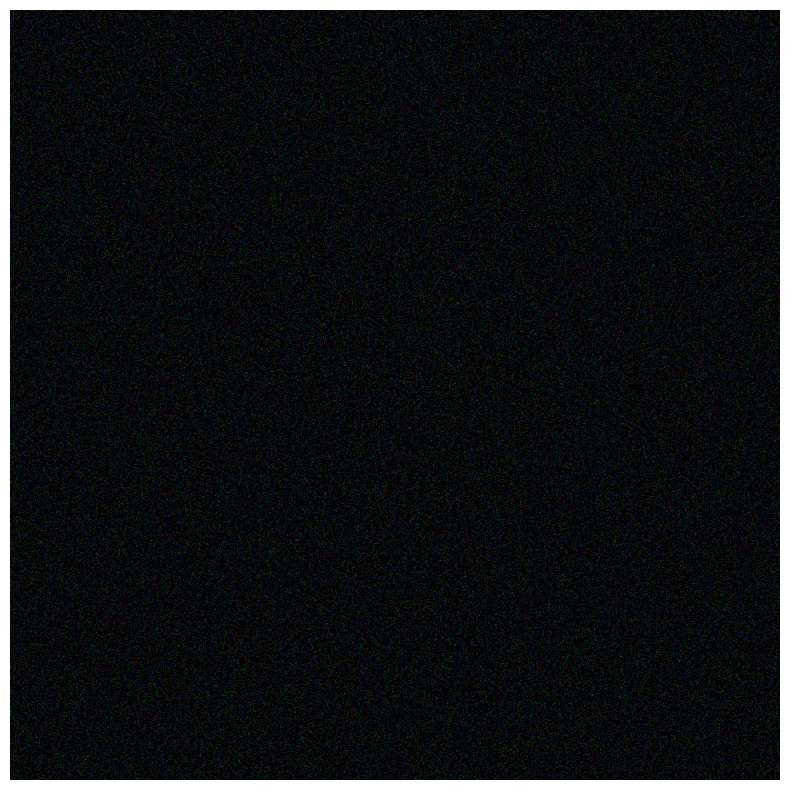

In [35]:
# rgb = make_lupton_rgb(1.0 * imgs[2], 1.05 * imgs[1], 1.2 * imgs[0], minimum=-0.03, stretch=1, Q=4)
rgb = make_lupton_rgb(0.9 * imgs[2], 1.05 * imgs[1], 1.2 * imgs[0], minimum=0, stretch=1, Q=3)
# fig, ax = plt.subplots(figsize=(20, 20))
fig, ax = plt.subplots(figsize=(10, 10))
plt.imshow(rgb)
plt.axis('off')

# plt.text(wid - 0.2 * wid, +5, filters[filt_idx[0]], 
         # fontsize=20, color='deepskyblue', va='center', ha='center')
# plt.text(wid, +5, filters[filt_idx[1]], 
         # fontsize=20, color='limegreen', va='center', ha='center')
# plt.text(wid + 0.2 * wid, +5, filters[filt_idx[2]], 
         # fontsize=20, color='orangered', va='center', ha='center')
# title = '$\mathrm{Age} = ' + f'{gal_kwargs["age"].to(u.Gyr).value:.1f}' + '\ \mathrm{Gyr}$, '
# title += '$\mathrm{[Fe/H]}=' + f'{gal_kwargs["feh"]:.1f}' + '$, '
# title += '$M_\star=10^{' + f'{np.log10(gal_kwargs["total_mass"]):.1f}' + '}\ M_\odot$, '
# title += '$D=' + str(int(gal_kwargs['distance'].to(u.Mpc).value)) + '$ Mpc'
# plt.title(title, fontsize=20)

# plt.savefig('/tigress/jiaxuanl/public_html/figure/SBF/Rosesim/sky_jaguar_trilegal_642s_new.png', bbox_inches='tight', dpi=200, transparent=True)

### Check https://tigress-web.princeton.edu/~jiaxuanl/figure/SBF/Rosesim/sky.png

---

In [21]:
dm = rosesim.read_L3_asdf("/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/sky_jaguar/F158_642s.asdf")

In [22]:
gwcs = dm.meta.wcs

In [25]:
gwcs.footprint()

array([[150.02843971,   2.19769392],
       [150.02843161,   2.35050203],
       [150.18136839,   2.35050203],
       [150.18136029,   2.19769392]])